# EE-411 Lottery Ticket Hypothesis - Experiment Template

**Author:** Xavier  
**Model:** Conv6
**Dataset:** CIFAR-10  
**Date:** 14/01/2026

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

In [1]:
import os, sys
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

cwd: /content
sys.path[0]: /content


In [2]:
from google.colab import drive
drive.mount("/content/drive")

KeyboardInterrupt: 

## 1. Setup and Imports

In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))  # from notebook/ to repo root


import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
import sys
sys.path.insert(0, "/content/drive/MyDrive/ee411-lottery-ticket-hypothesis")

In [6]:
!ls /content/drive/MyDrive/ee411-lottery-ticket-hypothesis
!ls /content/drive/MyDrive/ee411-lottery-ticket-hypothesis/shared

environment.yml		   notebook   requirements.txt	shared
experiment_template.ipynb  README.md  results
__init__.py  pruning.py  __pycache__  training_utils.py


In [7]:
# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [8]:
# CIFAR-10 Data Loading

# Define transforms
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Download and load datasets
train_dataset_full = torchvision.datasets.CIFAR10(
    root='../../data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data',
    train=False,
    download=True,
    transform=transform_test
)

# Split train into train/val (45k train, 5k val)
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# Create data loaders
batch_size = 60  # From paper

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

100%|██████████| 170M/170M [00:01<00:00, 102MB/s]


Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 750


### For MNIST (LeNet)

In [ ]:
# MNIST Data Loading (Uncomment if using LeNet)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# train_dataset_full = torchvision.datasets.MNIST(
#     root='../../data',
#     train=True,
#     download=True,
#     transform=transform
# )

# test_dataset = torchvision.datasets.MNIST(
#     root='../../data',
#     train=False,
#     download=True,
#     transform=transform
# )

# # Split train/val (55k train, 5k val)
# train_size = 55000
# val_size = 5000
# train_dataset, val_dataset = random_split(
#     train_dataset_full,
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(seed)
# )

# batch_size = 60

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# print(f"Train: {len(train_dataset)} samples")
# print(f"Val:   {len(val_dataset)} samples")
# print(f"Test:  {len(test_dataset)} samples")

## 3. Model Definition

**TODO: Define your model here**

In [9]:
import torch
import torch.nn as nn

class Conv6(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Conv-6: (64,64,pool) -> (128,128,pool) -> (256,256,pool)
        # All convs are 3x3 with padding=1 to preserve spatial size within each block.

        # CIFAR-10 input is (3, 32, 32)
        # After 3 pools: 32 -> 16 -> 8 -> 4, so final map is (256, 4, 4)
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Flatten size is 256*4*4 = 4096 for CIFAR-10
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model instance
model = Conv6().to(device)

# Print model info
total_params = count_parameters(model)
print(f"Model: Conv2")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Model: Conv2
Total parameters: 2,262,602

Model architecture:
Conv6(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequ

## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [10]:
# Training configuration (from paper)
# Adjust these based on your model!

learning_rate = 3e-4  # Conv-6 uses Adam with lr=3e-4
epochs = 27           # ~20K iterations / (45K samples / 60 batch) ≈ 27 epochs

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Training configuration:")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

# Train using shared training_utils
losses = fit(
    model=model,
    train_dataloader=train_loader,
    optimizer=optimizer,
    epochs=epochs,
    device=device
)

# Evaluate on test set
test_loss, test_accuracy = predict(model, test_loader, device)

print(f"\n{'='*60}")
print(f"Baseline Results")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Training configuration:
  Optimizer: Adam
  Learning rate: 0.0003
  Epochs: 27
  Batch size: 60

Starting training...

Epoch 0: Loss=1.5706411913235983
Epoch 1: Loss=1.0702333903312684
Epoch 2: Loss=0.81810882182916
Epoch 3: Loss=0.6641763431231181
Epoch 4: Loss=0.5376327851613363
Epoch 5: Loss=0.42879997509717943
Epoch 6: Loss=0.33254840488235154
Epoch 7: Loss=0.24412874877949556
Epoch 8: Loss=0.17579025475432475
Epoch 9: Loss=0.12904425024737914
Epoch 10: Loss=0.09966793431652089
Epoch 11: Loss=0.07971494989003985
Epoch 12: Loss=0.0780372842202584
Epoch 13: Loss=0.06459458635064463
Epoch 14: Loss=0.06242795350495726
Epoch 15: Loss=0.05277069655728216
Epoch 16: Loss=0.05236957155074924
Epoch 17: Loss=0.04805918141415653
Epoch 18: Loss=0.04663388042190733
Epoch 19: Loss=0.04642501211251753
Epoch 20: Loss=0.0415776766280178
Epoch 21: Loss=0.040512699507797754
Epoch 22: Loss=0.03940284425000815
Epoch 23: Loss=0.03709486702817958
Epoch 24: Loss=0.03530594796920195
Epoch 25: Loss=0.0347741

### Visualize Training

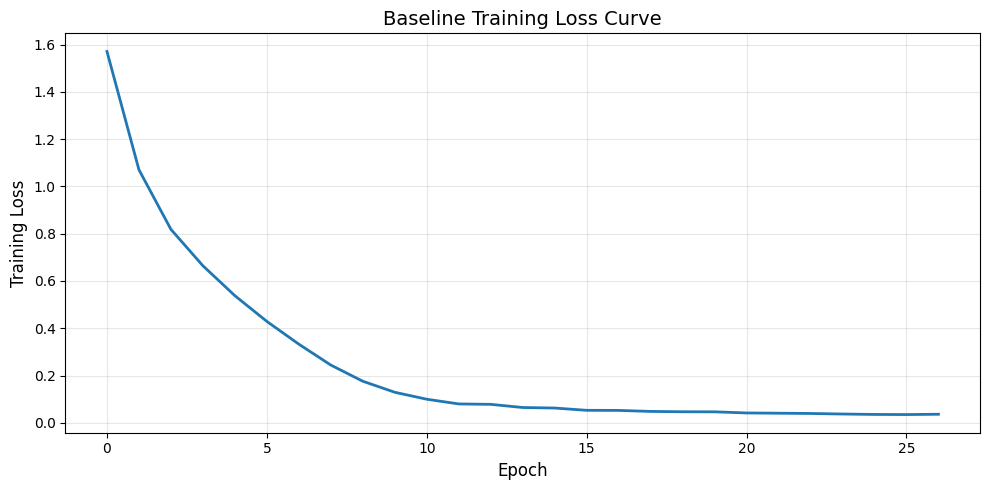

In [12]:
from pathlib import Path
save_dir = Path("/content/drive/MyDrive/ee411-lottery-ticket-hypothesis/results/figures")
save_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Baseline Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "baseline_training_loss.png", dpi=150)
plt.show()

### Save Baseline Model

In [14]:
from pathlib import Path
ckpt_dir = Path("/content/drive/MyDrive/ee411-lottery-ticket-hypothesis/results/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "test_accuracy": test_accuracy,
    },
    ckpt_dir / "baseline_checkpoint.pt"
)

print("Baseline model saved to results/checkpoints/baseline_model.pth")

Baseline model saved to results/checkpoints/baseline_model.pth


## 5. Iterative Pruning Experiments

Run the main pruning experiment from the paper.

In [15]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18'

pruning_config = get_pruning_config('conv6')  # Change this for your model

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")

# Or customize your own config
# pruning_config = {
#     'prune_rate_conv': 0.1,
#     'prune_rate_fc': 0.2,
#     'pruning_strategy': 'layerwise'
# }

Pruning Configuration:
  prune_rate_conv: 0.15
  prune_rate_fc: 0.2
  pruning_strategy: layerwise
  description: Conv-6 for CIFAR-10


In [16]:
# Create fresh model for pruning
model_pruning = Conv6().to(device)  # Replace with your model

# Run iterative pruning
results = iterative_pruning(
    model=model_pruning,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={'lr': learning_rate},
    device=device,
    config=pruning_config,
    n_rounds=5,           # Start with 10 rounds for testing
    epochs_per_round=20,   # Epochs per pruning round
    verbose=True
)

print("\nPruning experiment complete!")

Starting Iterative Pruning
Initial parameters: 2,262,602
Pruning strategy: layerwise
Conv prune rate: 15.0%
FC prune rate: 20.0%

Round 1/10


Epoch 1/15: 100%|██████████| 750/750 [00:06<00:00, 114.30it/s]


Epoch 1/15, Loss: 1.6183


Epoch 2/15: 100%|██████████| 750/750 [00:06<00:00, 122.87it/s]


Epoch 2/15, Loss: 1.1374


...

Epoch 14/15: 100%|██████████| 750/750 [00:06<00:00, 124.10it/s]


Epoch 14/15, Loss: 0.0787


Epoch 15/15: 100%|██████████| 750/750 [00:06<00:00, 122.73it/s]

Epoch 15/15, Loss: 0.0631



Round 10 Results:
  Test Accuracy: 79.12%
  Remaining Parameters: 1,867,588.0 (82.54%)

Iterative Pruning Complete!

Pruning experiment complete!


## 6. Analyze Results

Visualize and analyze the pruning results.

In [17]:
# Extract data for plotting
rounds = [r['round'] for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
remaining_params_pct = [r['remaining_params_pct'] for r in results]
remaining_params = [r['remaining_params'] for r in results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)


Pruning Results Summary
Round    Params %     Params          Test Acc %  
----------------------------------------------------------------------
1        82.54        1,867,588.0     78.18       
2        82.54        1,867,588.0     79.86       
3        82.54        1,867,588.0     79.91       
4        82.54        1,867,588.0     79.19       
5        82.54        1,867,588.0     79.66       
6        82.54        1,867,588.0     79.20       
7        82.54        1,867,588.0     79.37       
8        82.54        1,867,588.0     79.23       
9        82.54        1,867,588.0     79.97       
10       82.54        1,867,588.0     79.12       


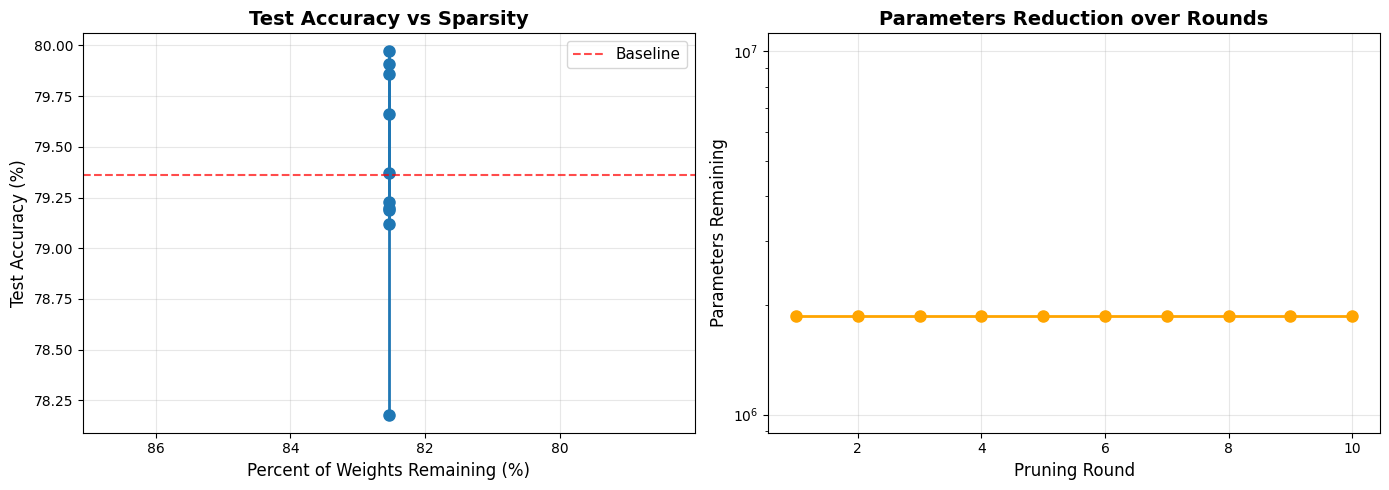


Figure saved to results/figures/pruning_results.png


In [19]:
from pathlib import Path

out_path = Path("/content/drive/MyDrive/ee411-lottery-ticket-hypothesis/results/figures/pruning_results.png")
out_path.parent.mkdir(parents=True, exist_ok=True)


# Visualize results (similar to paper Figure 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Test Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)
# ax1.axhline(y=test_accuracy, color='r', linestyle='--', label='Baseline', alpha=0.7) # If you are using CPU, use this line
ax1.axhline(y=test_accuracy.item(), color='r', linestyle='--', label='Baseline', alpha=0.7) # If you are using GPU (cuda), use this line
ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy vs Sparsity', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis()  # More sparse on the right

# Right plot: Parameters Remaining
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction over Rounds', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig(out_path, dpi=150)
plt.show()

print("\nFigure saved to results/figures/pruning_results.png")

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

In [20]:
# Identify winning tickets
baseline_accuracy = test_accuracy
winning_tickets = []

for r in results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets:
    best_ticket = min(winning_tickets, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")


Found 10 Winning Tickets!
Baseline Accuracy: 79.36%

Winning Tickets (accuracy >= 77.77%):
Round    Sparsity %   Params          Accuracy %  
----------------------------------------------------------------------
1        17.5         1,867,588.0     78.18       
2        17.5         1,867,588.0     79.86       
3        17.5         1,867,588.0     79.91       
4        17.5         1,867,588.0     79.19       
5        17.5         1,867,588.0     79.66       
6        17.5         1,867,588.0     79.20       
7        17.5         1,867,588.0     79.37       
8        17.5         1,867,588.0     79.23       
9        17.5         1,867,588.0     79.97       
10       17.5         1,867,588.0     79.12       

Best Winning Ticket:
  Round: 1
  Sparsity: 17.5%
  Parameters: 1,867,588.0
  Accuracy: 78.18%


## 8. Save Results

In [22]:

from pathlib import Path
import json

# Save results to JSON
results_dict = {
    "model": "Conv6",
    "dataset": "CIFAR-10",
    "baseline_accuracy": float(baseline_accuracy),
    "pruning_config": pruning_config,
    "pruning_results": results,
    "winning_tickets": winning_tickets,
}

out_path = Path("../../results/pruning_results.json")
out_path.parent.mkdir(parents=True, exist_ok=True)

with open(out_path, "w") as f:
    json.dump(results_dict, f, indent=2)

print(f"Results saved to {out_path.resolve()}")


Results saved to /results/pruning_results.json


## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?